# Conditional QA + RAG for federated learning

My note. I moved this demo off the lab-policy example. Federated learning is the topic I actually want the notebook to answer.

The condition is the application, not a job title. Healthcare, banking, and mobile phones do not share one answer. Hospitals keep scans, banks keep transactions, phones keep keystrokes. Retrieval finds a note. Then I check which setting the question named. I only keep an answer when that note is actually close.

Three outcomes I want in the printout:

- answer, and quote the note
- ask which application, when I forgot to name healthcare, banking, or mobile
- refuse, when the question is not in these notes

I am not calling an outside LLM here. I print the prompt I would send, and I print the passage that prompt is allowed to use.

## Notes I wrote on federated learning

Thirteen short notes. One is the plain definition. The other twelve are the same four questions in three applications: where the data stay, what the model is for, why privacy matters, and what the network is like.

I wrote them myself so I already know which note a question should cite.

In [1]:
import math
import re
import matplotlib.pyplot as plt

CHUNKS = [
    {"id": "fl-def", "condition": "general", "text": "Federated learning trains one shared model while each client keeps its own data and sends only a model update."},
    {"id": "health-data", "condition": "healthcare", "text": "In healthcare, hospitals keep patient records on site and train a shared model without pooling those records."},
    {"id": "bank-data", "condition": "banking", "text": "In banking, each bank keeps transaction records inside the institution and trains a shared model without exchanging raw transactions."},
    {"id": "mobile-data", "condition": "mobile", "text": "In a mobile setting, each phone keeps typing and app data on the device and trains a shared model without uploading the raw text."},
    {"id": "health-app", "condition": "healthcare", "text": "A healthcare application detects disease from local hospital scans while the scans never leave the hospital."},
    {"id": "bank-app", "condition": "banking", "text": "A banking application is a fraud detection task across banks while the transactions stay inside each bank."},
    {"id": "mobile-app", "condition": "mobile", "text": "A mobile application predicts the next word from on-device typing while the messages stay on the phone."},
    {"id": "health-privacy", "condition": "healthcare", "text": "Healthcare training treats patient privacy as a serious issue because a record can identify a patient."},
    {"id": "bank-privacy", "condition": "banking", "text": "Banking training protects transaction logs because they reveal how a customer spends, and privacy is a serious issue."},
    {"id": "mobile-privacy", "condition": "mobile", "text": "Mobile training treats keystroke privacy as a serious issue because the data sit on a personal phone."},
    {"id": "health-net", "condition": "healthcare", "text": "Hospitals usually have a stable network, so a training round can send a larger model update."},
    {"id": "bank-net", "condition": "banking", "text": "Banks usually have a stable link, so a training round can send a fuller model update."},
    {"id": "mobile-net", "condition": "mobile", "text": "Phones often drop offline, so a training round must accept that many clients miss the update."}
]

THRESHOLD = 0.25
ALIASES = {
    "healthcare": ("healthcare", "hospital", "hospitals"),
    "banking": ("banking", "bank", "banks"),
    "mobile": ("mobile", "phone", "phones"),
}

print(f"{len(CHUNKS)} notes")
for chunk in CHUNKS:
    print(f"{chunk['id']:16}  {chunk['condition']:11}  {chunk['text']}")

13 notes
fl-def            general      Federated learning trains one shared model while each client keeps its own data and sends only a model update.
health-data       healthcare   In healthcare, hospitals keep patient records on site and train a shared model without pooling those records.
bank-data         banking      In banking, each bank keeps transaction records inside the institution and trains a shared model without exchanging raw transactions.
mobile-data       mobile       In a mobile setting, each phone keeps typing and app data on the device and trains a shared model without uploading the raw text.
health-app        healthcare   A healthcare application detects disease from local hospital scans while the scans never leave the hospital.
bank-app          banking      A banking application is a fraud detection task across banks while the transactions stay inside each bank.
mobile-app        mobile       A mobile application predicts the next word from on-device typing while t

## Where I put the cutoff

I printed scores before I trusted them. "What is the capital of France?" is 0. "I am working on mobile. What is the weather in Paris?" still contains the word mobile, so it is not zero, but the best note is only about 0.16. The privacy question with no application is different: the three privacy notes all land near 0.33. I set THRESHOLD to 0.25 so the weather question is refused and the privacy question is kept long enough for me to ask which setting.

On the healthcare records question, health-data and health-privacy are close, because both talk about patients. The records note still comes first. I am leaving that as it is.

In [1]:
STOP = set(
    "i am a an the what is in can do how many when until of to for my me are you your it this that with only if they on from by working about should worry does use who why used".split()
)

def tokenize(text):
    raw = re.findall(r"[a-z0-9]+", text.lower())
    tokens = []
    for token in raw:
        if len(token) > 3 and token.endswith("s"):
            token = token[:-1]
        if token in STOP or len(token) <= 1:
            continue
        tokens.append(token)
    return tokens

def build_index(chunks):
    docs = [tokenize(chunk["condition"] + " " + chunk["text"]) for chunk in chunks]
    df = {}
    for doc in docs:
        for token in set(doc):
            df[token] = df.get(token, 0) + 1
    n_docs = len(docs)

    def vectorize(tokens):
        counts = {}
        for token in tokens:
            counts[token] = counts.get(token, 0) + 1
        length = len(tokens) or 1
        weights = {}
        for token, count in counts.items():
            idf = math.log((n_docs + 1) / (df.get(token, 0) + 1)) + 1
            weights[token] = (count / length) * idf
        return weights

    return [vectorize(doc) for doc in docs], vectorize

DOC_VECTORS, vectorize = build_index(CHUNKS)

def cosine(left, right):
    dot = norm_l = norm_r = 0.0
    for token, weight in left.items():
        norm_l += weight * weight
        if token in right:
            dot += weight * right[token]
    for weight in right.values():
        norm_r += weight * weight
    if norm_l == 0 or norm_r == 0:
        return 0.0
    return dot / math.sqrt(norm_l * norm_r)

def retrieve(question):
    query = vectorize(tokenize(question))
    ranked = []
    for chunk, doc_vector in zip(CHUNKS, DOC_VECTORS):
        ranked.append({**chunk, "score": cosine(query, doc_vector)})
    ranked.sort(key=lambda row: row["score"], reverse=True)
    return ranked

print("Healthcare records question, top notes:")
for hit in retrieve("I am working on healthcare. Who keeps the patient records?")[:4]:
    print(f"{hit['score']:.3f}  {hit['id']}")

Healthcare records question, top notes:
0.658  health-data
0.614  health-privacy
0.202  bank-data
0.166  health-app


## How I read the application off the question

"Healthcare" and "hospital" both mean the healthcare notes. "Bank" and "banking" mean the banking notes. "Mobile" and "phone" mean the mobile notes. If none of those words appear, I do not guess an application.

One exception I allowed: "What is federated learning?" names no application, but only the definition note matches. One matching setting is enough, so that question is answered from fl-def. If three privacy notes match and no setting was named, I ask instead of picking healthcare just because it was first.

In [ ]:
def detect_condition(question):
    text = question.lower()
    hits = []
    for condition, words in ALIASES.items():
        if any(re.search(rf"\b{word}\b", text) for word in words):
            hits.append(condition)
    if len(hits) == 1:
        return hits[0]
    return None

def build_prompt(question, hit, condition):
    # This is the text I would send to an LLM. One passage only.
    lines = [
        "Answer the question using only the passage.",
        "If the passage does not contain the answer, say you do not know.",
        f"Application setting: {condition or 'not stated'}",
        "",
        "Passage:",
        f"[{hit['id']}] {hit['text']}",
        "",
        f"Question: {question}",
    ]
    return "\n".join(lines)

def respond(question):
    ranked = retrieve(question)
    stated = detect_condition(question)
    best = ranked[0]["score"]
    refusal = "I cannot answer that from the federated learning notes."
    if best < THRESHOLD:
        return {
            "decision": "abstain",
            "condition": stated,
            "id": None,
            "score": best,
            "answer": refusal,
        }
    condition = stated
    if condition is None:
        top = [hit for hit in ranked if hit["score"] >= 0.20][:3]
        found = {hit["condition"] for hit in top}
        if len(found) != 1:
            return {
                "decision": "clarify",
                "condition": None,
                "id": None,
                "score": best,
                "answer": "Please say whether this is healthcare, banking, or a mobile setting.",
            }
        condition = next(iter(found))
    scoped = [hit for hit in ranked if hit["condition"] == condition]
    if not scoped or scoped[0]["score"] < THRESHOLD:
        return {
            "decision": "abstain",
            "condition": condition,
            "id": None,
            "score": best,
            "answer": refusal,
        }
    hit = scoped[0]
    return {
        "decision": "answer",
        "condition": condition,
        "id": hit["id"],
        "score": hit["score"],
        "answer": hit["text"],
        "prompt": build_prompt(question, hit, condition),
    }

## The prompt I would send to a model

One passage, the application, and the question. The line under the prompt is that same passage. I want the cited sentence on a demo this small, not a paraphrase.

If I connect a model later, I only send the prompt when the decision is answer. A privacy question with no application, and a weather question, should stay as my own messages.

In [1]:
sample = respond("I am working on healthcare. Who keeps the patient records?")
print(sample["prompt"])
print()
print("offline answer:", sample["answer"])

Answer the question using only the passage.
If the passage does not contain the answer, say you do not know.
Application setting: healthcare

Passage:
[health-data] In healthcare, hospitals keep patient records on site and train a shared model without pooling those records.

Question: I am working on healthcare. Who keeps the patient records?

offline answer: In healthcare, hospitals keep patient records on site and train a shared model without pooling those records.


## Questions I wrote, all about federated learning

I wrote the expected note before I looked at the scores again.

1. Healthcare, who keeps the patient records. I expect health-data.
2. Banking, what the fraud task is. I expect bank-app.
3. Privacy, and I never say which application. I expect a question back.
4. Capital of France. Refuse. It is not in the notes.
5. What federated learning is. I expect the definition, fl-def.
6. Mobile, why phones miss a round. I expect mobile-net.
7. A hospital detecting disease from scans. I expect health-app.
8. Mobile, plus the weather in Paris. The word mobile is a trap. Refuse.
9. Why banks protect transaction logs. I expect bank-privacy.

In [1]:
DEMOS = [
    ("I am working on healthcare. Who keeps the patient records?", "answer", "health-data"),
    ("I am working on banking. What is the fraud detection task?", "answer", "bank-app"),
    ("What privacy issue should I worry about?", "clarify", None),
    ("What is the capital of France?", "abstain", None),
    ("What is federated learning?", "answer", "fl-def"),
    ("I am working on mobile. Why do phones miss a training round?", "answer", "mobile-net"),
    ("How does a hospital detect disease from local scans?", "answer", "health-app"),
    ("I am working on mobile. What is the weather in Paris?", "abstain", None),
    ("Why do banks protect transaction logs?", "answer", "bank-privacy")
]

rows = []
correct = 0
for question, expected, expected_id in DEMOS:
    result = respond(question)
    ok = result["decision"] == expected and result["id"] == expected_id
    correct += int(ok)
    rows.append(result)
    flag = "ok  " if ok else "MISS"
    cited = result["id"] or "-"
    print(f"{flag}  {result['decision']:8}  {result['score']:.3f}  {cited:14}  {question}")
    print(f"      {result['answer']}")

print(f"\n{correct}/{len(DEMOS)} demo questions matched the note I expected.")

ok    answer    0.658  health-data     I am working on healthcare. Who keeps the patient records?
      In healthcare, hospitals keep patient records on site and train a shared model without pooling those records.
ok    answer    0.616  bank-app        I am working on banking. What is the fraud detection task?
      A banking application is a fraud detection task across banks while the transactions stay inside each bank.
ok    clarify   0.340  -               What privacy issue should I worry about?
      Please say whether this is healthcare, banking, or a mobile setting.
ok    abstain   0.000  -               What is the capital of France?
      I cannot answer that from the federated learning notes.
ok    answer    0.400  fl-def          What is federated learning?
      Federated learning trains one shared model while each client keeps its own data and sends only a model update.
ok    answer    0.544  mobile-net      I am working on mobile. Why do phones miss a training round?
    

## What I see in the printout

Six answers cite the note I wanted, including the short definition of federated learning. The privacy question does not guess healthcare. It asks. France is refused, and so is the mobile weather question, even though that one says mobile.

The fraud line is the application I care about most in the banking block: the answer is the fraud-detection task, and the transactions stay in the bank. The healthcare disease line does the same thing for scans. The phone line is the communication constraint I always forget to write down: clients miss the round because they drop offline.

## Two plots

The bars are the healthcare records question. health-data is first. health-privacy is right behind it.

The counts on the nine questions: 6 answers, 1 clarify, 2 refuses.

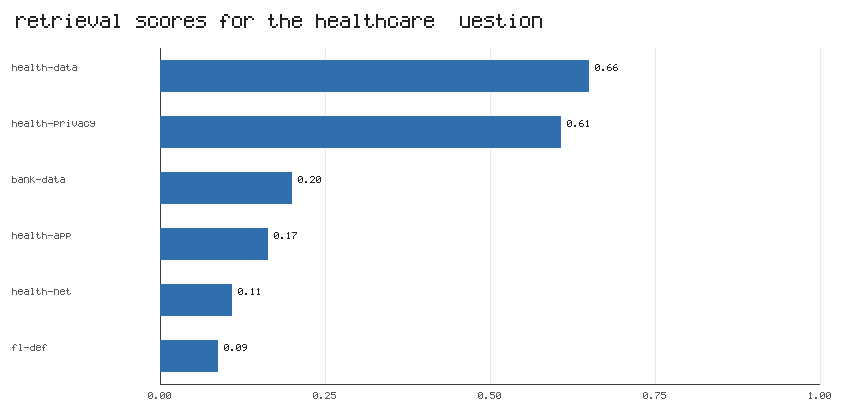

In [1]:
top = retrieve(DEMOS[0][0])[:6]
fig, ax = plt.subplots(figsize=(8, 4.2))
ax.barh([hit["id"] for hit in top][::-1], [hit["score"] for hit in top][::-1], color="#2f6fad")
ax.set_xlim(0, 1)
ax.set_xlabel("cosine similarity")
ax.set_title("Retrieval scores for the healthcare records question")
fig.tight_layout()
plt.show()

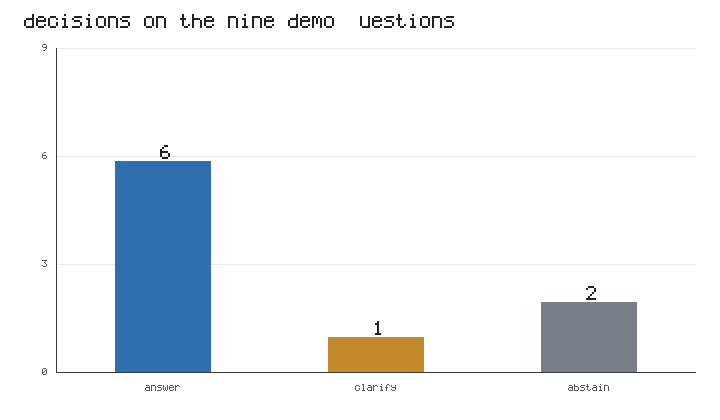

In [1]:
from collections import Counter

counts = Counter(row["decision"] for row in rows)
order = ["answer", "clarify", "abstain"]
colors = {"answer": "#2f6fad", "clarify": "#c4892a", "abstain": "#787e88"}
fig, ax = plt.subplots(figsize=(6.5, 4))
ax.bar(order, [counts[name] for name in order], color=[colors[name] for name in order])
ax.set_ylabel("questions")
ax.set_ylim(0, len(DEMOS))
ax.set_title("Decisions on the nine demo questions")
fig.tight_layout()
plt.show()

## One more question, about the hospital network

I did not put this one in the nine. Hospitals usually have a stable link, so I expect the note that says the round can send a larger update.

In [1]:
def ask(question):
    result = respond(question)
    print("decision: ", result["decision"])
    print("condition:", result["condition"])
    print("score:    ", round(result["score"], 3))
    print("note:     ", result["id"])
    print("answer:   ", result["answer"])
    return result

ask("In healthcare, can the training round send a larger update?")

decision:  answer
condition: healthcare
score:     0.649
note:      health-net
answer:    Hospitals usually have a stable network, so a training round can send a larger model update.


## If I connect a real model later

The notes, the application check, and the 0.25 cutoff stay. The quoted sentence is the only piece a language model would rewrite, and only after the decision is answer.

If I skip the gate, a model will invent a privacy rule for a question that never said healthcare, banking, or mobile. That is the mistake this notebook is here to catch.